e:\python aiml
===== FIRST 5 ROWS =====
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

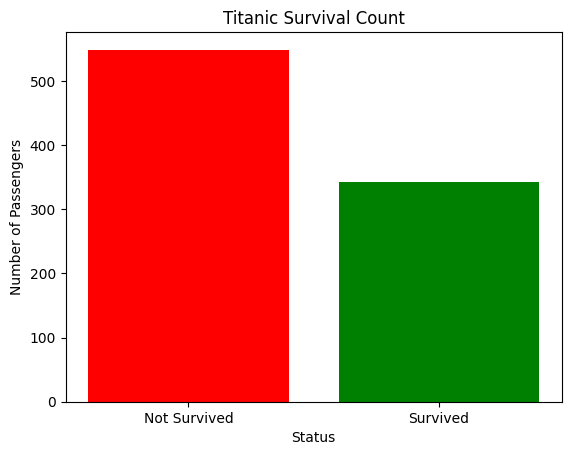


===== GENDER COUNT =====
Sex
male      577
female    314
Name: count, dtype: int64


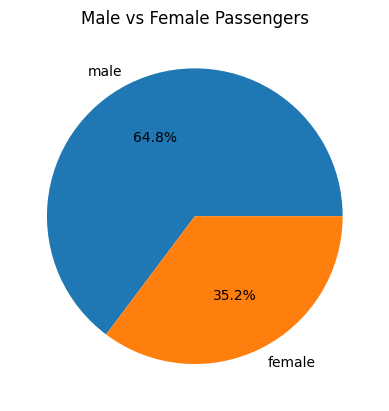


===== PASSENGER CLASS COUNT =====
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


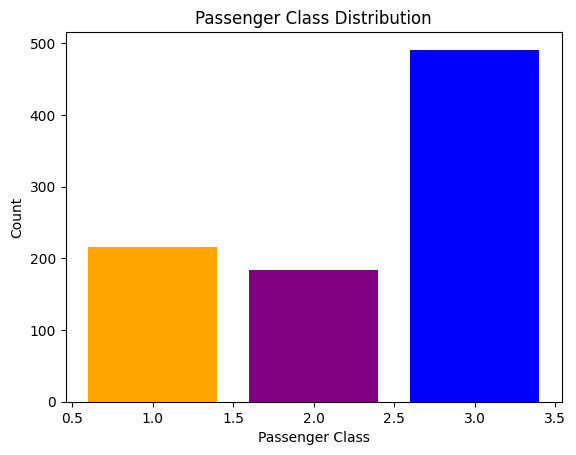

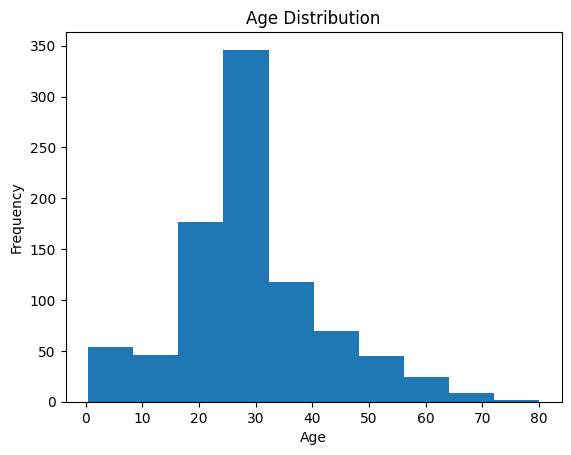

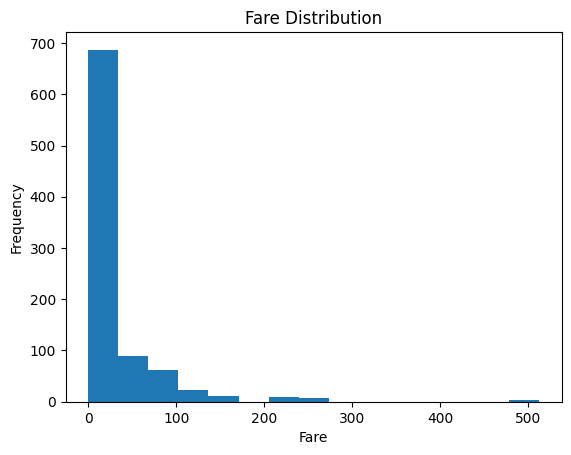


===== SURVIVAL BY GENDER =====
Survived    0    1
Sex               
female     81  233
male      468  109


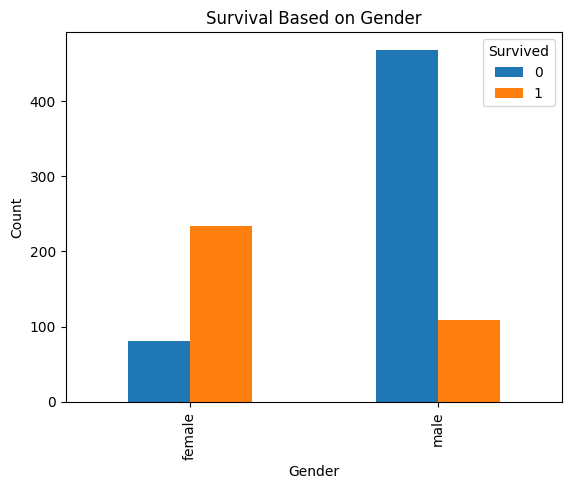


===== SURVIVAL BY PASSENGER CLASS =====
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


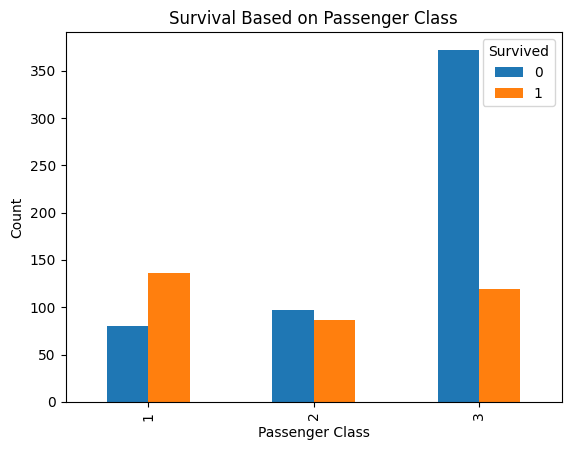


===== CORRELATION MATRIX =====
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.033207 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.069809 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.331339  0.083081  0.018443   
Age             0.033207 -0.069809 -0.331339  1.000000 -0.232625 -0.179191   
SibSp          -0.057527 -0.035322  0.083081 -0.232625  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.179191  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.091566  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.091566  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  

Titanic EDA Completed Successfully!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
print(os.getcwd())

# CSV file load
df = pd.read_csv("Titanic.csv")

print("===== FIRST 5 ROWS =====")
print(df.head())

# Dataset Information

print("\n===== DATASET INFO =====")
print(df.info())

print("\n===== DATASET SHAPE =====")
print(df.shape)

print("\n===== COLUMN NAMES =====")
print(df.columns)

# Check Missing Values

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

# Fill Missing Age Values

df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill Embarked Missing Values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("\n===== AFTER HANDLING MISSING VALUES =====")
print(df.isnull().sum())

# Survival Count

survival_count = df["Survived"].value_counts()

print("\n===== SURVIVAL COUNT =====")
print(survival_count)

# Survival Bar Chart

plt.bar(["Not Survived", "Survived"],
        survival_count,
        color=["red", "green"])

plt.title("Titanic Survival Count")
plt.xlabel("Status")
plt.ylabel("Number of Passengers")

plt.show()

# Gender Count

gender_count = df["Sex"].value_counts()

print("\n===== GENDER COUNT =====")
print(gender_count)

#  Gender Pie Chart

plt.pie(gender_count,
        labels=gender_count.index,
        autopct='%1.1f%%')

plt.title("Male vs Female Passengers")

plt.show()

#  Passenger Class Count

pclass_count = df["Pclass"].value_counts()

print("\n===== PASSENGER CLASS COUNT =====")
print(pclass_count)

# Passenger Class Bar Chart

plt.bar(pclass_count.index,
        pclass_count.values,
        color=["blue", "orange", "purple"])

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

# Age Distribution Histogram

plt.hist(df["Age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# EXTRA PLOT 1 : Fare Distribution

plt.hist(df["Fare"], bins=15)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

# EXTRA PLOT 2 : Survival by Gender

survival_gender = pd.crosstab(df["Sex"], df["Survived"])

print("\n===== SURVIVAL BY GENDER =====")
print(survival_gender)

survival_gender.plot(kind="bar")

plt.title("Survival Based on Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

# EXTRA PLOT 3 : Survival by Passenger Class

survival_class = pd.crosstab(df["Pclass"], df["Survived"])

print("\n===== SURVIVAL BY PASSENGER CLASS =====")
print(survival_class)

survival_class.plot(kind="bar")

plt.title("Survival Based on Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

#  Correlation Matrix

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print("\n===== CORRELATION MATRIX =====")
print(correlation)

print("\nTitanic EDA Completed Successfully!")